In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 55 concetti unici e 633 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.7502
Epoca [10/100] | Loss: 0.2234
Epoca [20/100] | Loss: 0.0718
Epoca [30/100] | Loss: 0.0281
Epoca [40/100] | Loss: 0.0144
Epoca [50/100] | Loss: 0.0091
Epoca [60/100] | Loss: 0.0067
Epoca [70/100] | Loss: 0.0053
Epoca [80/100] | Loss: 0.0047
Epoca [90/100] | Loss: 0.0042
Epoca [100/100] | Loss: 0.0039

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: leg | hops
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

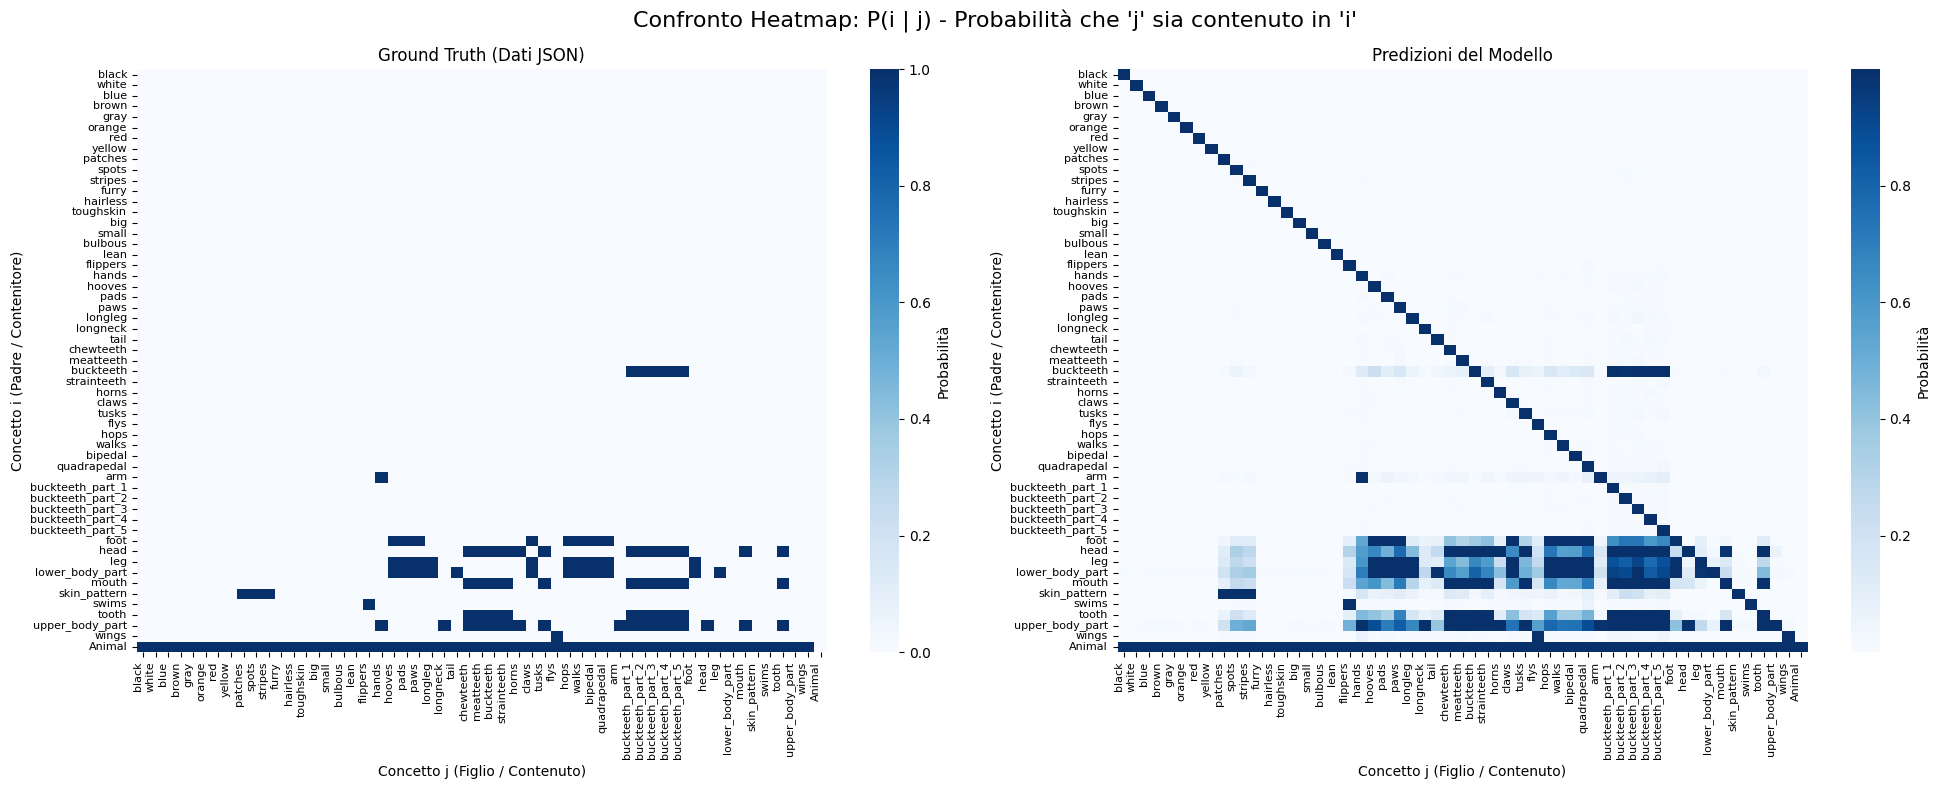

In [10]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

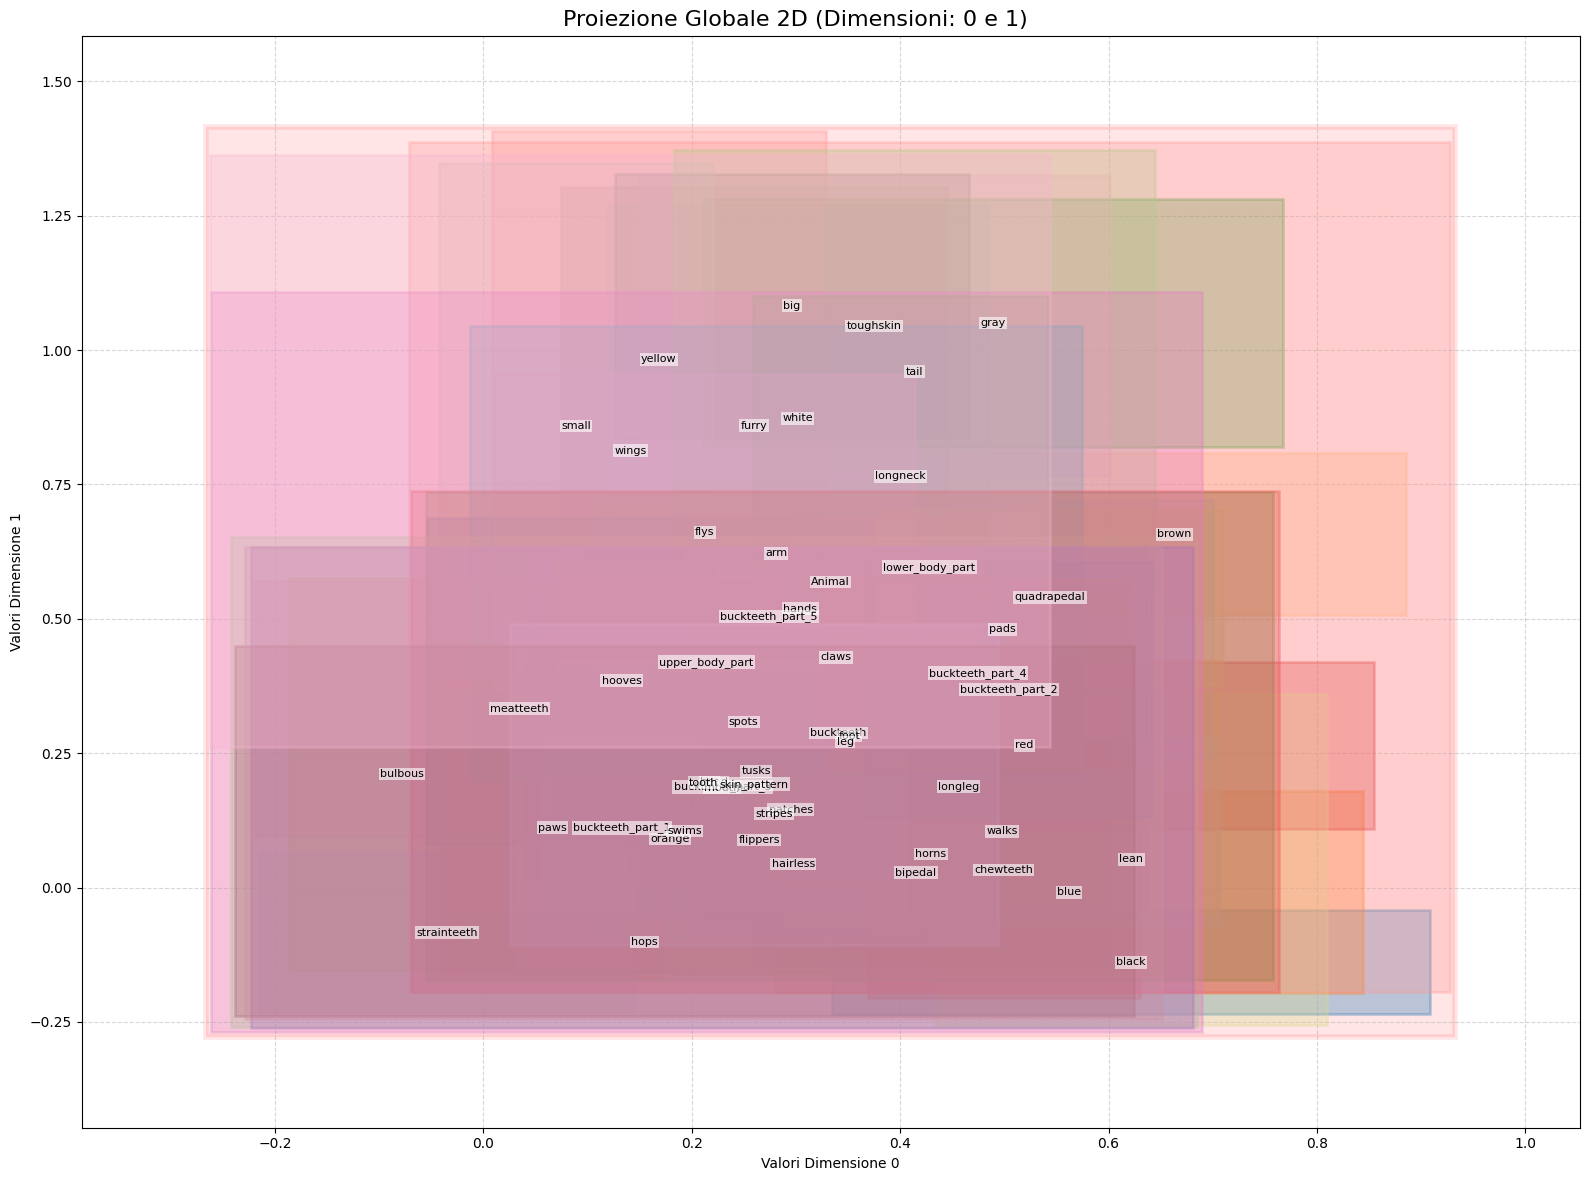

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

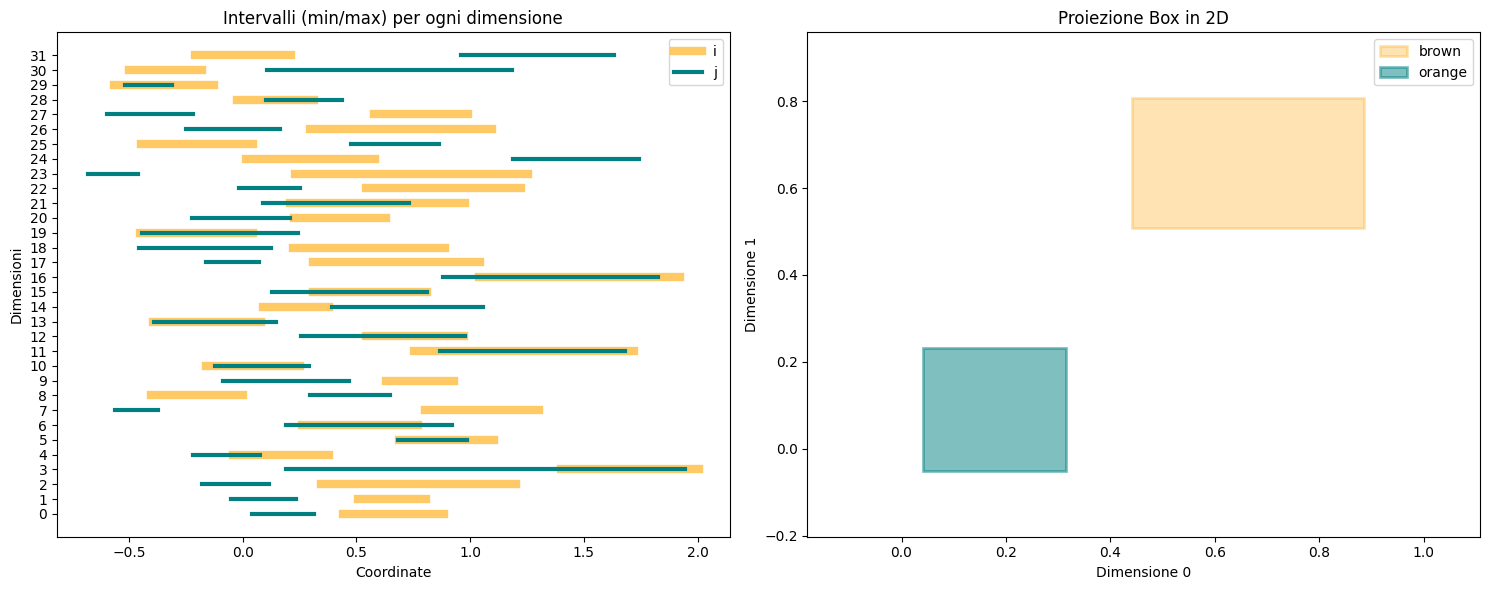

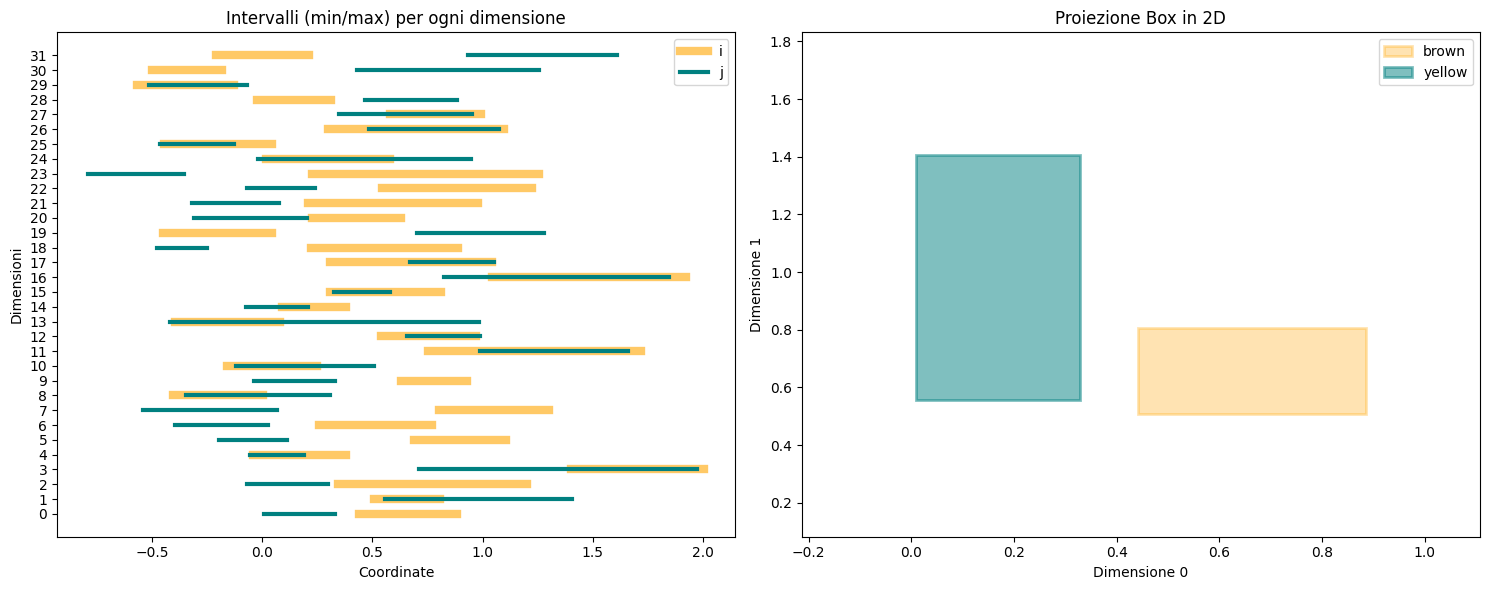

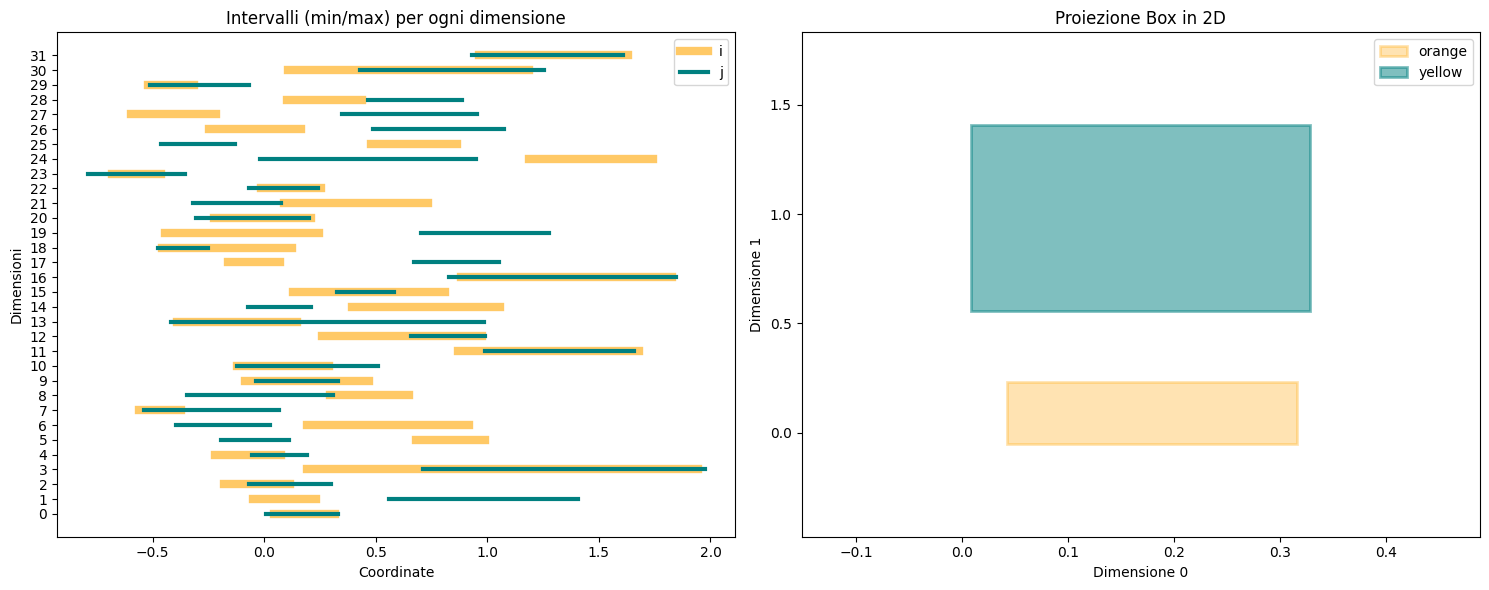

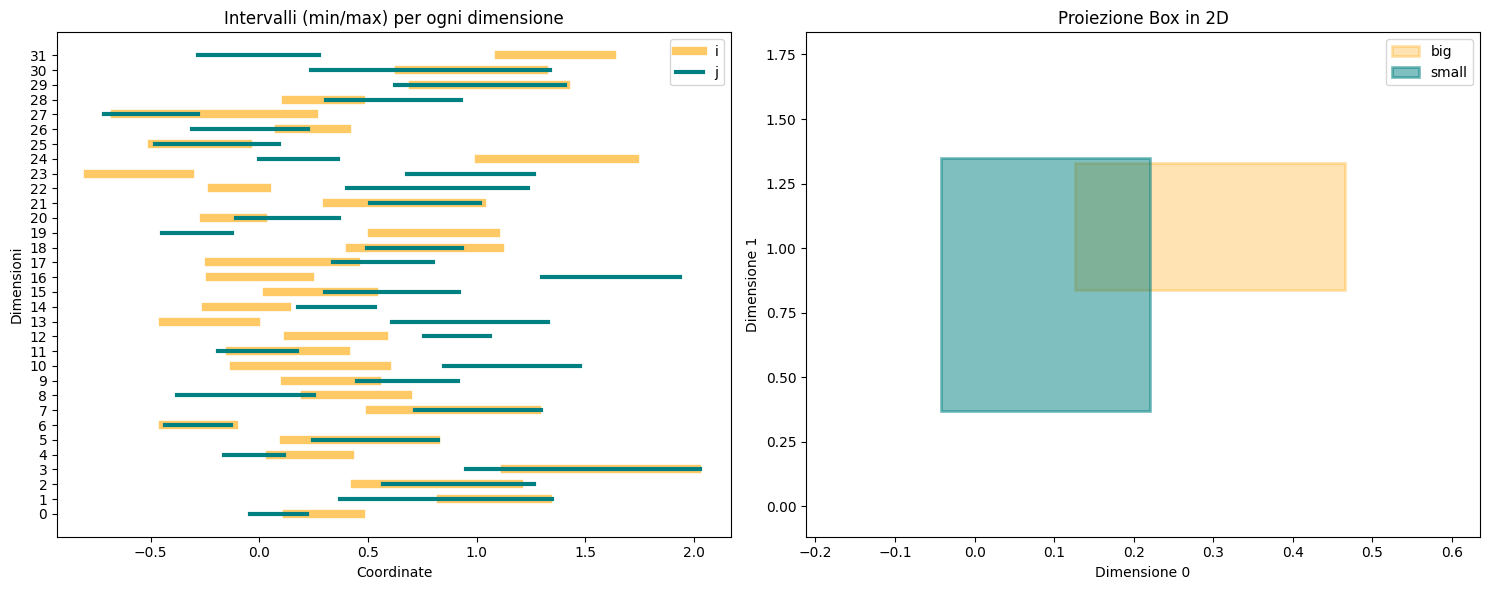

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [13]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

## CBM

### Load dataset

In [14]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [15]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [16]:
box_dict = get_box_dict(box_model, id2concept)

In [17]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [18]:
from src.CHM.model import ConceptBottleneckClassifier, ConceptPredictor
from src.CHM.train import joint_training
import matplotlib.pyplot as plt
from src.CHM.test import test_joint_cbm
from src.utils.plot import plot_history, plot_test_results

### CBM with boxes

#### Train

In [30]:
b_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
b_concept_criterion = nn.BCEWithLogitsLoss()

b_optimizer = torch.optim.Adam(list(b_cls.parameters()) + list(b_concept_predictor.parameters()), lr=0.0005)

lambda_concept = 1.0
gamma_hierarchy = 0.5

info = "boxes"

b_history = joint_training(
    classifier=b_cls,
    concept_predictor=b_concept_predictor,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    optimizer=b_optimizer,
    criterion_cls=b_cls_criterion,
    criterion_concept=b_concept_criterion,
    epochs=7,
    device=device,
    lambda_c=lambda_concept,
    gamma_h=gamma_hierarchy,
    info=info,
    bipolar=False,
)


========== Addestramento Joint CBM (con Logica Gerarchica) ==========
Epoca   1/7 | TRAIN: Loss=1.326, Acc=78.2% | VAL: Loss=0.771, Acc=89.3%
Epoca   2/7 | TRAIN: Loss=0.653, Acc=92.1% | VAL: Loss=0.722, Acc=89.1%
Epoca   3/7 | TRAIN: Loss=0.548, Acc=94.1% | VAL: Loss=0.656, Acc=90.9%
Epoca   4/7 | TRAIN: Loss=0.495, Acc=95.1% | VAL: Loss=0.631, Acc=91.6%
Epoca   5/7 | TRAIN: Loss=0.454, Acc=96.1% | VAL: Loss=0.649, Acc=90.9%
Epoca   6/7 | TRAIN: Loss=0.415, Acc=97.2% | VAL: Loss=0.636, Acc=91.3%
Epoca   7/7 | TRAIN: Loss=0.396, Acc=97.5% | VAL: Loss=0.683, Acc=90.1%


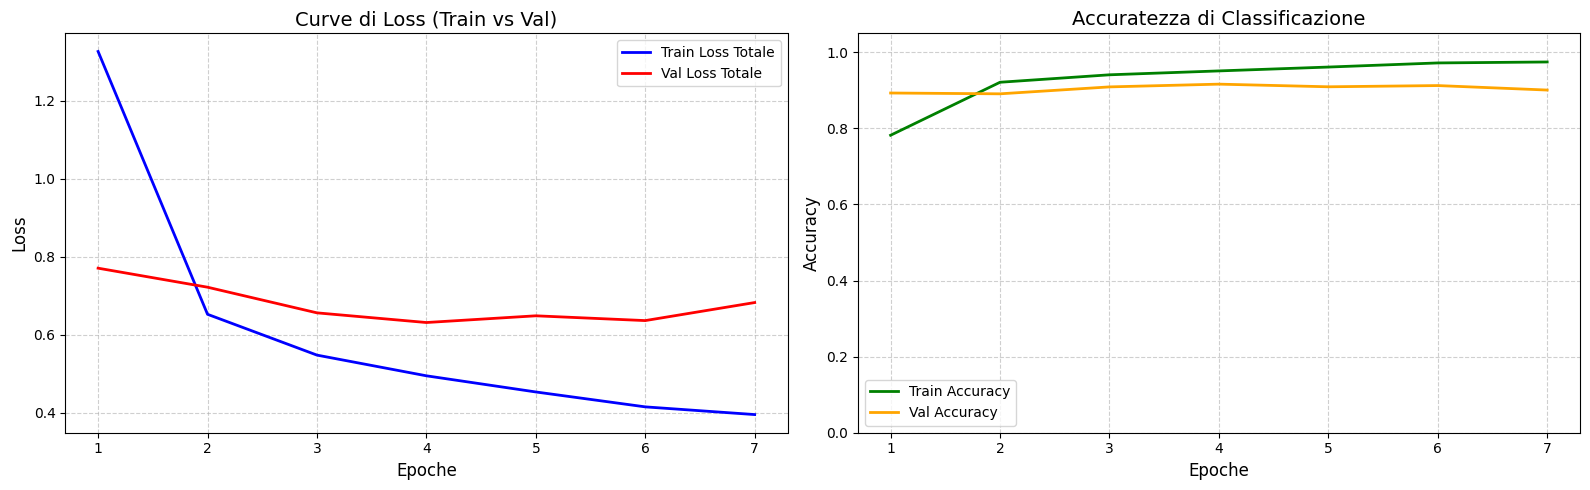

In [31]:
plot_history(b_history)

#### Test

In [32]:
accuracy, preds, labels = test_joint_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)


Inizio valutazione sul Test Set (Modalità Joint)...
Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.84% (6781/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.93      0.88      0.91       209
           1       0.84      0.98      0.90       170
           2       0.94      0.79      0.86        58
           3       0.70      0.79      0.74        38
           4       0.97      0.98      0.98       110
           5       0.90      0.94      0.92       149
           6       0.92      0.95      0.94       329
           7       0.94      0.91      0.92       207
           8       0.49      0.57      0.53        35
           9       0.81      0.90      0.85       100

   micro avg       0.89      0.92      0.90      1405
   macro avg       0.84      0.87      0.86      1405
weighted avg       0.89      0.92      0.90      1405



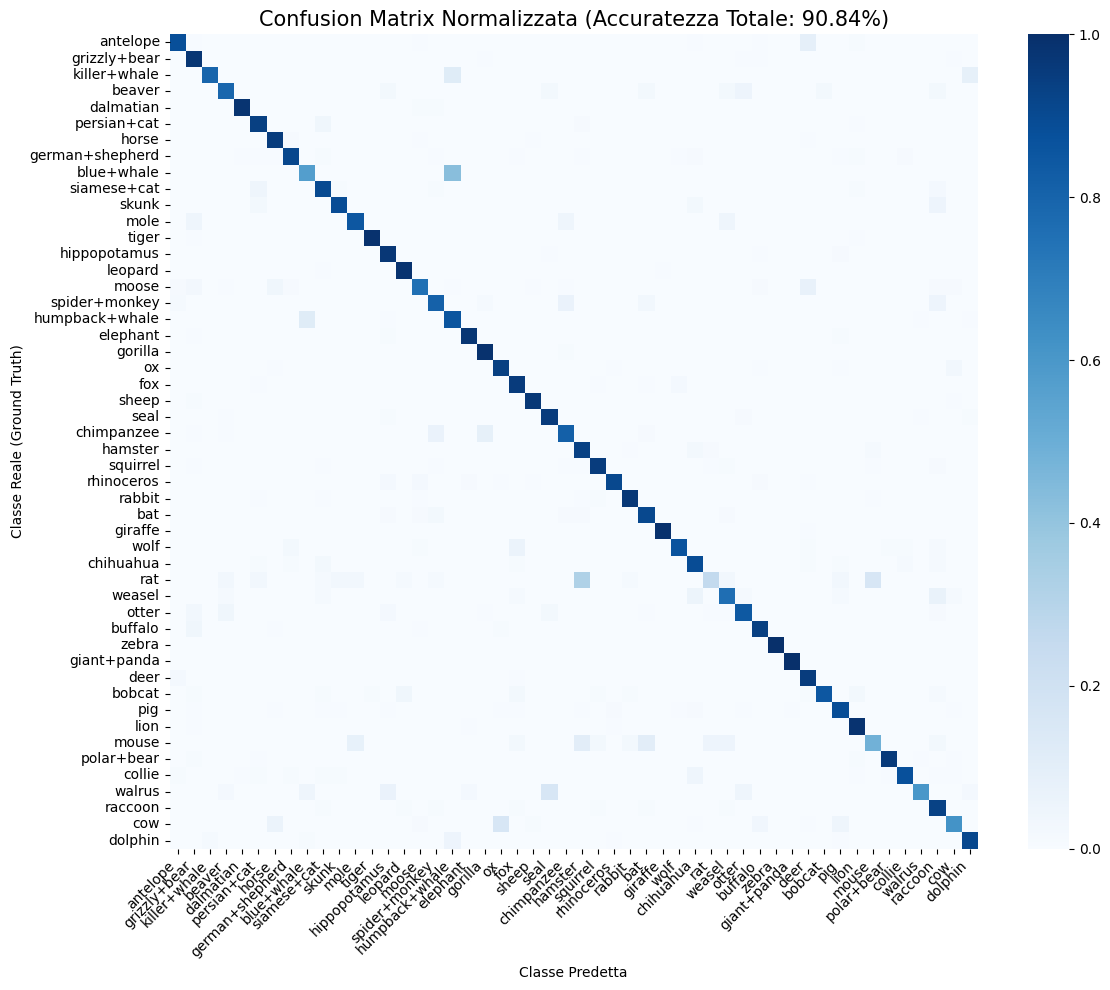


Analisi degli Errori Principali:
 - 43 volte: 'cow' è stato scambiato per 'ox'
 - 20 volte: 'rat' è stato scambiato per 'hamster'
 - 19 volte: 'antelope' è stato scambiato per 'deer'
 - 17 volte: 'humpback+whale' è stato scambiato per 'blue+whale'
 - 16 volte: 'cow' è stato scambiato per 'horse'


In [33]:
plot_test_results(accuracy, preds, labels, class_names=classes)

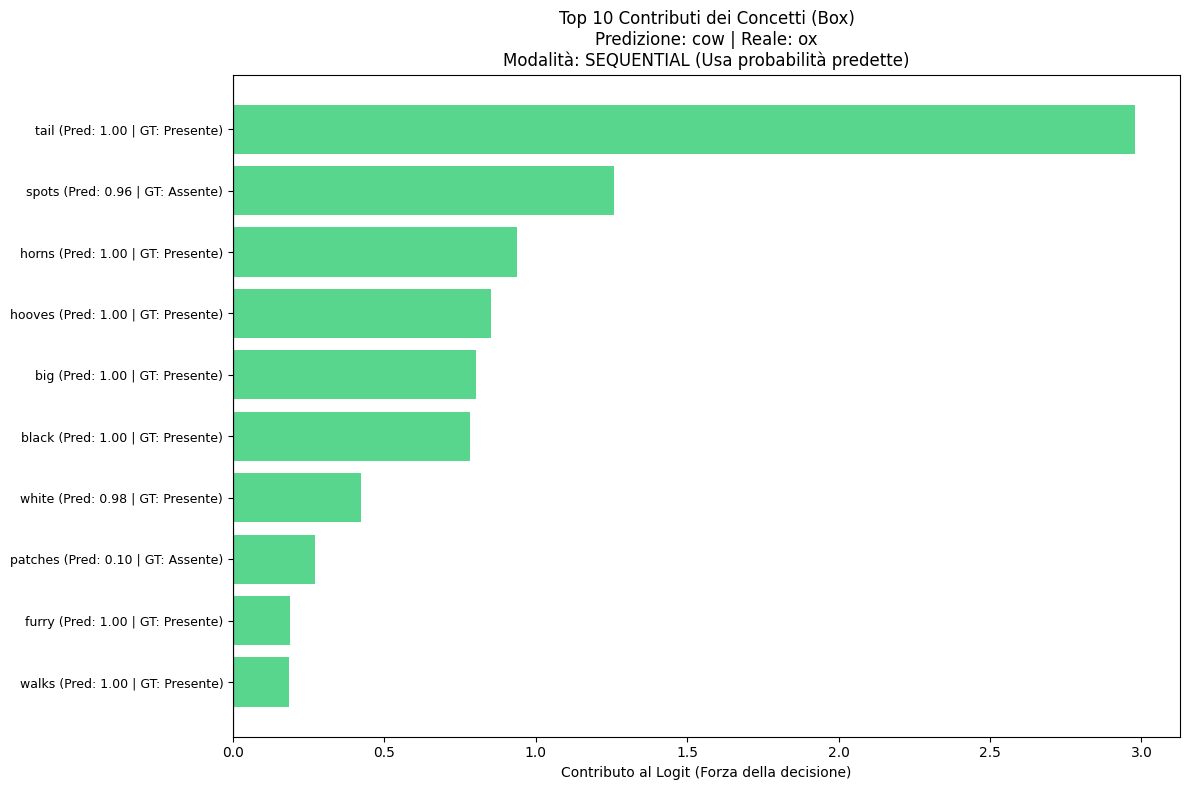

False

In [24]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=b_concept_predictor,
    target_class="ox"
)

### CBM with cond prob distrib

#### Train

In [27]:
info = "rel_matrix"
bipolar = True
cp_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
cp_optimizer = torch.optim.Adam(cp_cls.parameters(), lr=0.001)
cp_criterion = nn.CrossEntropyLoss()

cp_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
cp_concept_optimizer = torch.optim.Adam(cp_concept_predictor.parameters(), lr=0.001)
cp_concept_criterion = nn.BCEWithLogitsLoss()

cp_conc_history, cp_cls_history = sequential_training(
    cp_cls,
    cp_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    cp_optimizer,  
    cp_concept_optimizer,
    cp_criterion,
    cp_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.3814 | Acc: 96.1734 || Val Loss: 2.4274 | Val Acc: 97.2277
Loss: 2.1052 | Acc: 97.6087 || Val Loss: 2.1569 | Val Acc: 97.4829
Loss: 1.8178 | Acc: 97.9162 || Val Loss: 2.1017 | Val Acc: 97.5550
Loss: 1.6534 | Acc: 98.0895 || Val Loss: 2.0258 | Val Acc: 97.6334
Loss: 1.5438 | Acc: 98.2110 || Val Loss: 2.0292 | Val Acc: 97.6694
Loss: 1.4535 | Acc: 98.3174 || Val Loss: 1.9876 | Val Acc: 97.6987
Loss: 1.3798 | Acc: 98.4056 || Val Loss: 1.9893 | Val Acc: 97.7201
Loss: 1.3183 | Acc: 98.4748 || Val Loss: 2.0470 | Val Acc: 97.6548
Loss: 1.2676 | Acc: 98.5375 || Val Loss: 2.0187 | Val Acc: 97.6865
Loss: 1.2274 | Acc: 98.5836 || Val Loss: 2.0033 | Val Acc: 97.7162
Loss: 1.1912 | Acc: 98.6375 || Val Loss: 2.0693 | Val Acc: 97.6889
Loss: 1.1613 | Acc: 98.6639 || Val Loss: 2.0608 | Val Acc: 97.6996
Loss: 1.1317 | Acc: 98.6925 || Val Loss: 2.0752 | Val Acc: 97.7186
Loss: 1.1057 | Acc: 98.7293 || Val Loss: 2.0627 | Val Ac

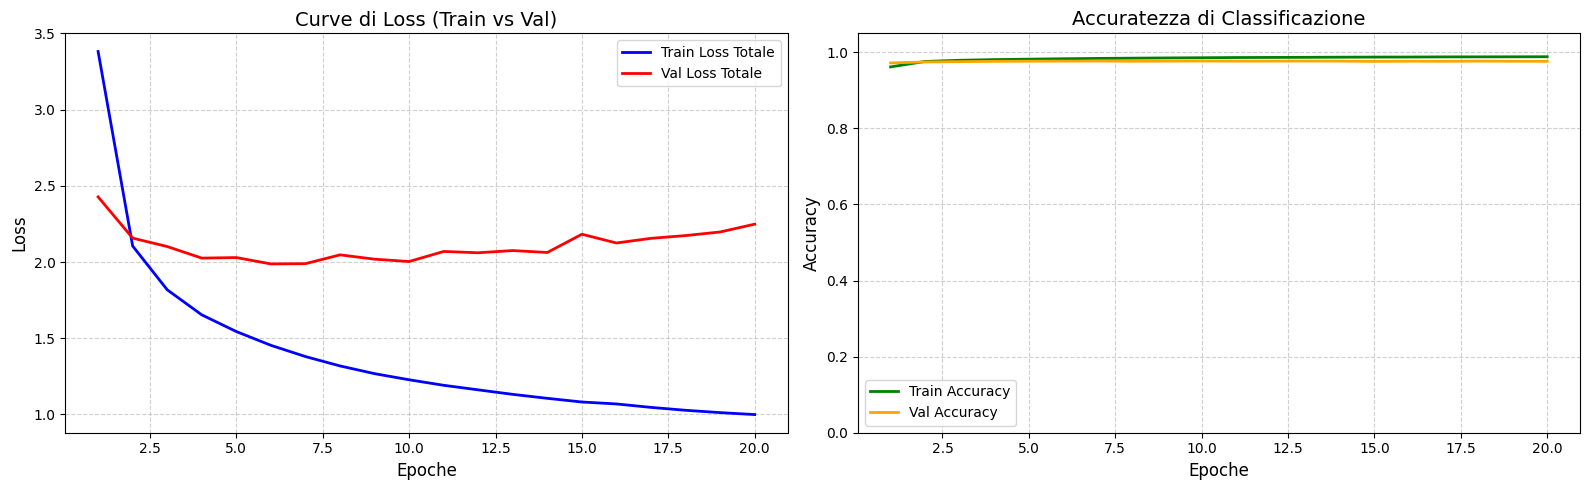

In [28]:
plot_history(cp_conc_history)

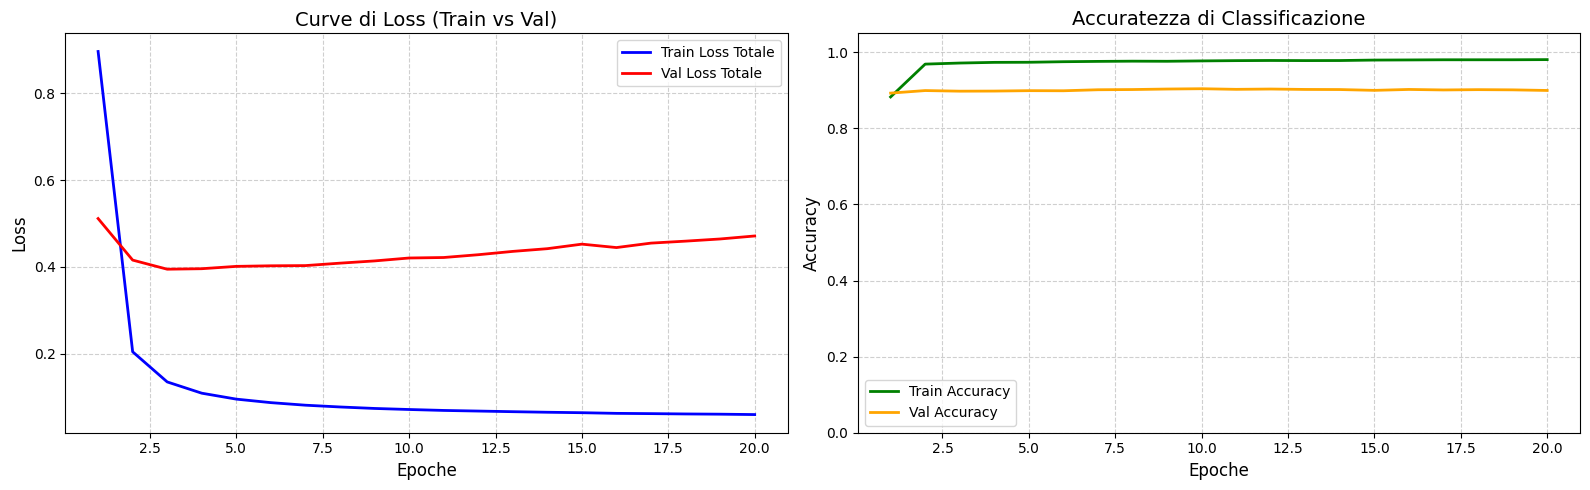

In [29]:
plot_history(cp_cls_history)

#### Test

In [30]:
cp_accuracy, cp_preds, cp_labels = test_sequential_cbm(
    cp_cls,
    cp_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 89.73% (6698/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       209
           1       0.86      0.95      0.90       170
           2       0.81      0.79      0.80        58
           3       0.75      0.71      0.73        38
           4       0.96      0.99      0.97       110
           5       0.94      0.91      0.92       149
           6       0.94      0.93      0.93       329
           7       0.87      0.86      0.87       207
           8       0.36      0.29      0.32        35
           9       0.78      0.86      0.82       100

   micro avg       0.87      0.89      0.88      1405
   macro avg       0.81      0.82      0.81      1405
weighted avg       0.87      0.89      0.88      1405



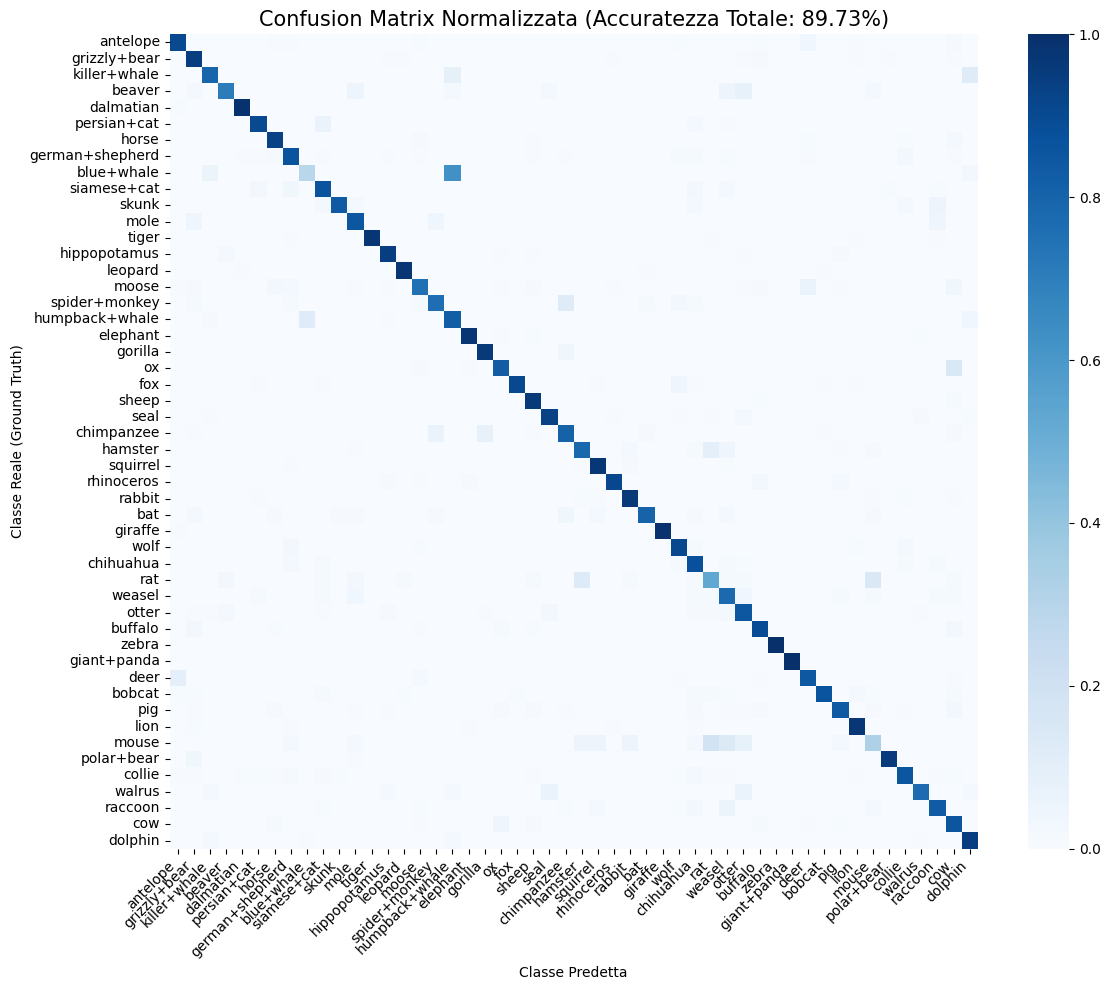


Analisi degli Errori Principali:
 - 26 volte: 'deer' è stato scambiato per 'antelope'
 - 22 volte: 'ox' è stato scambiato per 'cow'
 - 22 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 17 volte: 'humpback+whale' è stato scambiato per 'blue+whale'
 - 15 volte: 'hamster' è stato scambiato per 'rat'


In [31]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

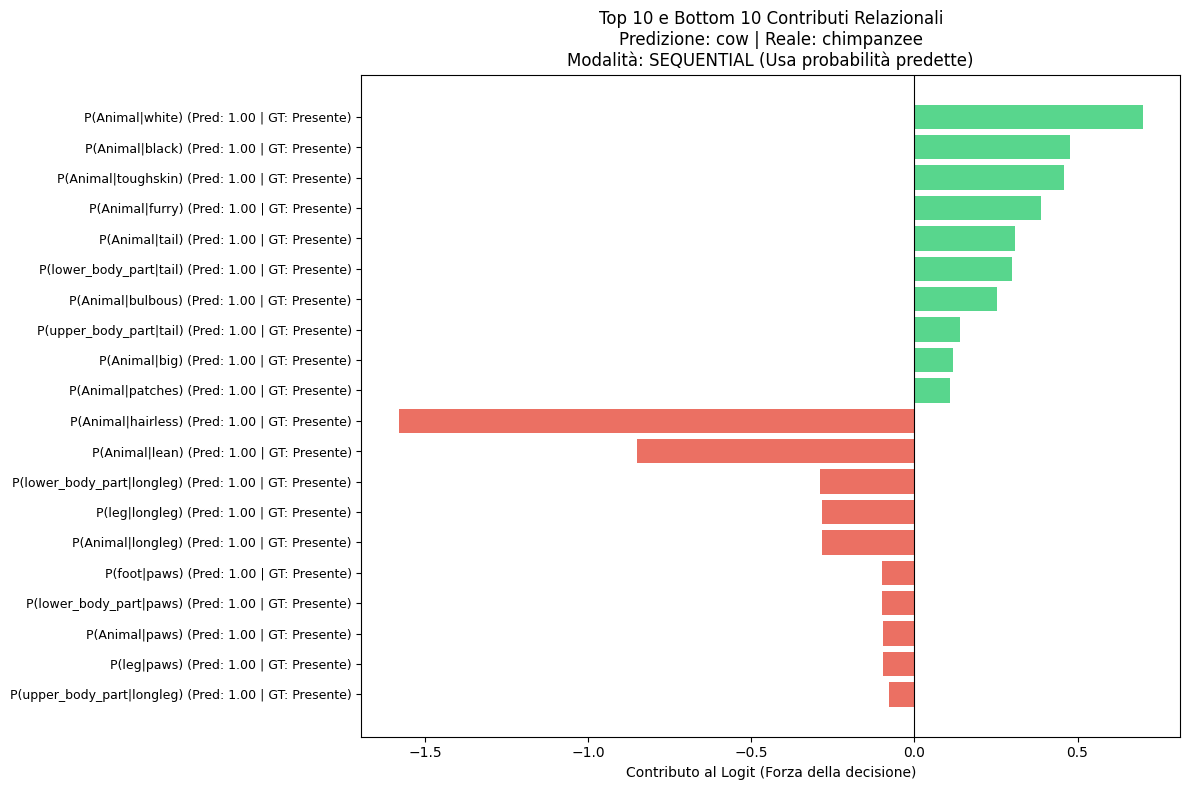

False

In [32]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=cp_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM standard

In [33]:
info = "concepts"
c_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
c_optimizer = torch.optim.Adam(c_cls.parameters(), lr=0.001)
c_criterion = nn.CrossEntropyLoss()


c_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
c_concept_optimizer = torch.optim.Adam(c_concept_predictor.parameters(), lr=0.001)
c_concept_criterion = nn.BCEWithLogitsLoss()

c_conc_history, c_cls_history = sequential_training(
    c_cls,
    c_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    c_optimizer,  
    c_concept_optimizer,
    c_criterion,
    c_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.3525 | Acc: 96.2003 || Val Loss: 2.4026 | Val Acc: 97.2131
Loss: 2.0988 | Acc: 97.5961 || Val Loss: 2.1780 | Val Acc: 97.4259
Loss: 1.8143 | Acc: 97.8980 || Val Loss: 2.0975 | Val Acc: 97.5584
Loss: 1.6493 | Acc: 98.1075 || Val Loss: 2.0342 | Val Acc: 97.6256
Loss: 1.5323 | Acc: 98.2410 || Val Loss: 2.0035 | Val Acc: 97.6529
Loss: 1.4468 | Acc: 98.3303 || Val Loss: 1.9934 | Val Acc: 97.6948
Loss: 1.3816 | Acc: 98.4054 || Val Loss: 2.0124 | Val Acc: 97.7099
Loss: 1.3153 | Acc: 98.4840 || Val Loss: 2.0145 | Val Acc: 97.6855
Loss: 1.2665 | Acc: 98.5421 || Val Loss: 1.9891 | Val Acc: 97.7444
Loss: 1.2308 | Acc: 98.5822 || Val Loss: 1.9834 | Val Acc: 97.7274
Loss: 1.1929 | Acc: 98.6263 || Val Loss: 2.0398 | Val Acc: 97.6991
Loss: 1.1591 | Acc: 98.6691 || Val Loss: 2.0667 | Val Acc: 97.6928
Loss: 1.1321 | Acc: 98.6908 || Val Loss: 2.0781 | Val Acc: 97.6850
Loss: 1.1010 | Acc: 98.7323 || Val Loss: 2.0908 | Val Ac

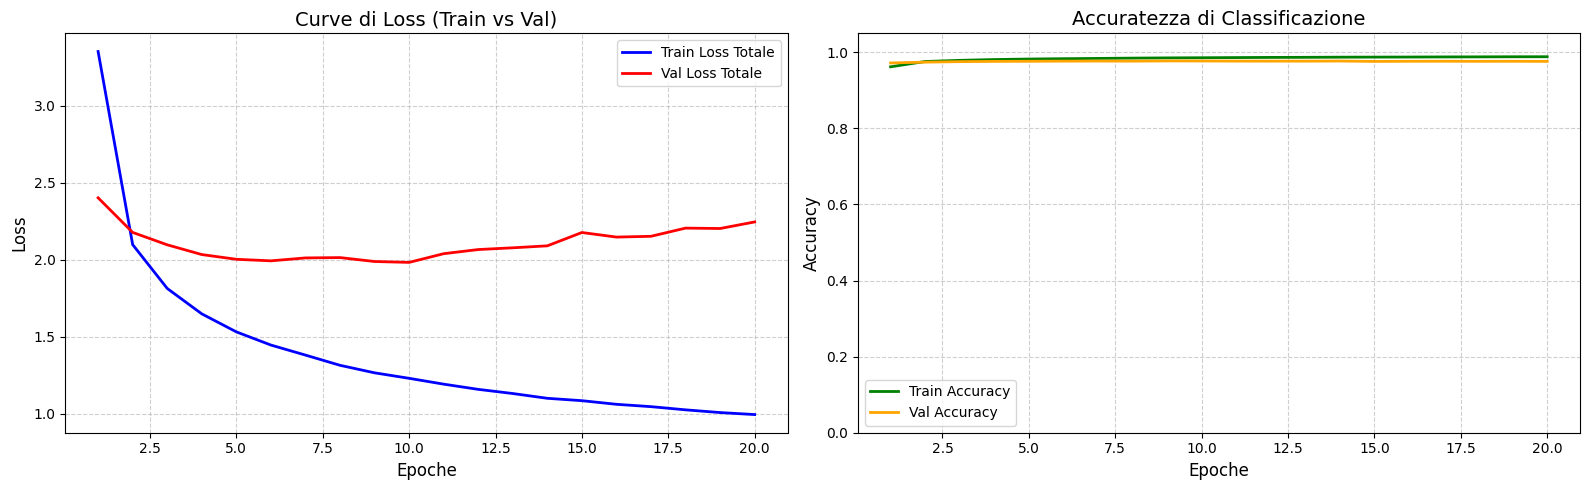

In [35]:
from src.utils.plot import plot_history
plot_history(c_conc_history)

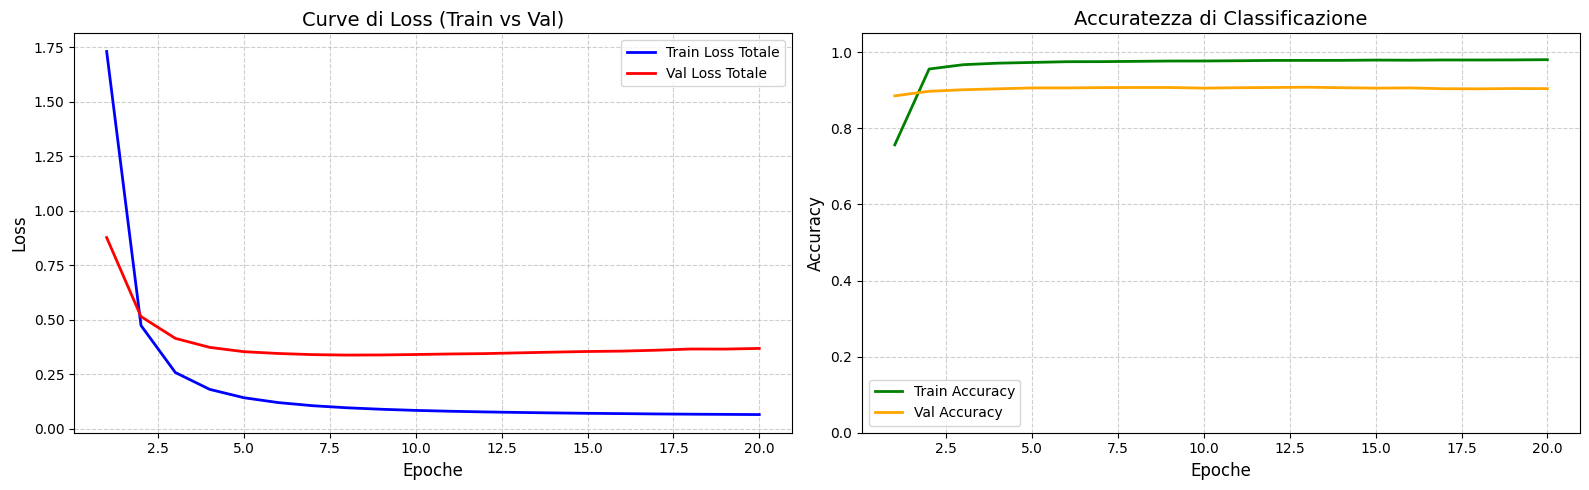

In [36]:
plot_history(c_cls_history)

In [37]:
c_accuracy, c_preds, c_labels = test_sequential_cbm(
    c_cls,
    c_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.66% (6768/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       209
           1       0.89      0.95      0.92       170
           2       0.83      0.84      0.84        58
           3       0.69      0.76      0.72        38
           4       0.96      0.99      0.97       110
           5       0.96      0.91      0.93       149
           6       0.97      0.93      0.95       329
           7       0.86      0.88      0.87       207
           8       0.38      0.29      0.33        35
           9       0.74      0.86      0.79       100

   micro avg       0.88      0.89      0.89      1405
   macro avg       0.81      0.83      0.82      1405
weighted avg       0.88      0.89      0.89      1405



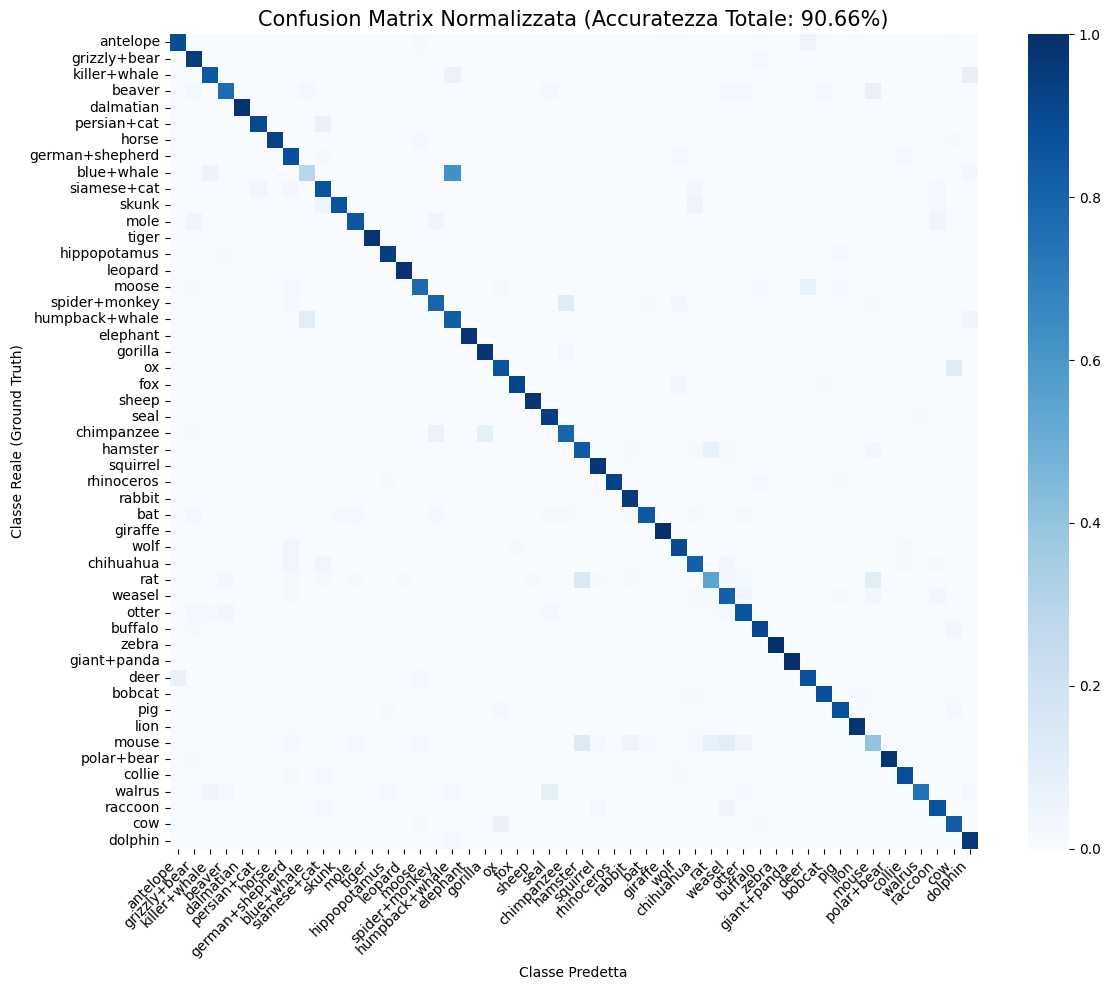


Analisi degli Errori Principali:
 - 22 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 20 volte: 'deer' è stato scambiato per 'antelope'
 - 19 volte: 'cow' è stato scambiato per 'ox'
 - 18 volte: 'ox' è stato scambiato per 'cow'
 - 15 volte: 'humpback+whale' è stato scambiato per 'blue+whale'


In [38]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

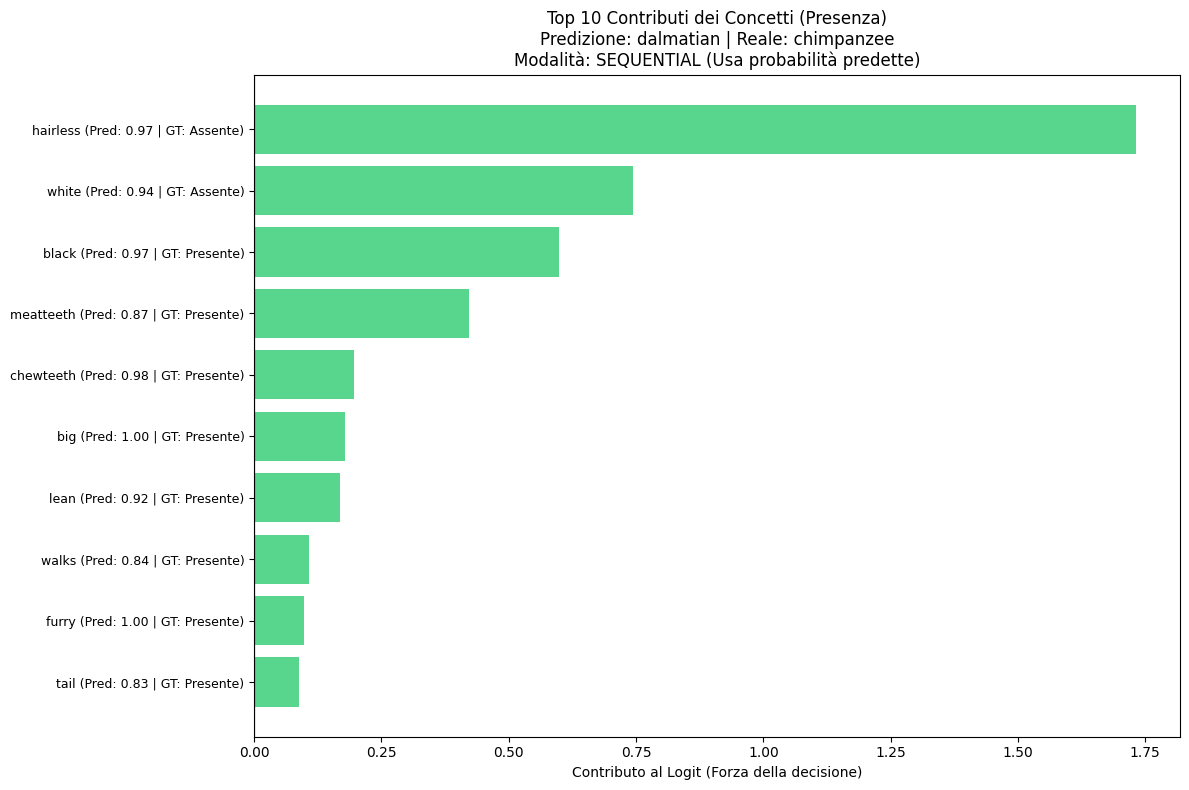

False

In [39]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    c_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=c_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM ALL

#### Train

In [40]:
info = "all"
bipolar = True
a_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
a_optimizer = torch.optim.Adam(a_cls.parameters(), lr=0.001)
a_criterion = nn.CrossEntropyLoss()

a_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
a_concept_optimizer = torch.optim.Adam(a_concept_predictor.parameters(), lr=0.001)
a_concept_criterion = nn.BCEWithLogitsLoss()

a_conc_history, a_cls_history = sequential_training(
    a_cls,
    a_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    a_optimizer,  
    a_concept_optimizer,
    a_criterion,
    a_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.3757 | Acc: 96.1723 || Val Loss: 2.4228 | Val Acc: 97.1965
Loss: 2.0926 | Acc: 97.6025 || Val Loss: 2.1647 | Val Acc: 97.4990
Loss: 1.8175 | Acc: 97.9290 || Val Loss: 2.0916 | Val Acc: 97.5871
Loss: 1.6536 | Acc: 98.0960 || Val Loss: 2.0226 | Val Acc: 97.6568
Loss: 1.5324 | Acc: 98.2371 || Val Loss: 1.9901 | Val Acc: 97.6719
Loss: 1.4508 | Acc: 98.3269 || Val Loss: 2.0069 | Val Acc: 97.6558
Loss: 1.3740 | Acc: 98.4260 || Val Loss: 1.9789 | Val Acc: 97.7274
Loss: 1.3138 | Acc: 98.4847 || Val Loss: 2.0038 | Val Acc: 97.7060
Loss: 1.2750 | Acc: 98.5327 || Val Loss: 2.0449 | Val Acc: 97.6514
Loss: 1.2309 | Acc: 98.5736 || Val Loss: 2.0267 | Val Acc: 97.6875
Loss: 1.1950 | Acc: 98.6243 || Val Loss: 2.0574 | Val Acc: 97.6938
Loss: 1.1526 | Acc: 98.6726 || Val Loss: 2.0741 | Val Acc: 97.6524
Loss: 1.1339 | Acc: 98.6955 || Val Loss: 2.0725 | Val Acc: 97.6977
Loss: 1.1064 | Acc: 98.7235 || Val Loss: 2.1321 | Val Ac

#### Test

In [41]:
a_accuracy, a_preds, a_labels = test_sequential_cbm(
    a_cls,
    a_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 89.56% (6686/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       209
           1       0.85      0.94      0.89       170
           2       0.76      0.88      0.82        58
           3       0.68      0.71      0.69        38
           4       0.96      0.98      0.97       110
           5       0.95      0.90      0.92       149
           6       0.94      0.94      0.94       329
           7       0.87      0.82      0.84       207
           8       0.35      0.31      0.33        35
           9       0.72      0.88      0.79       100

   micro avg       0.87      0.88      0.88      1405
   macro avg       0.80      0.83      0.81      1405
weighted avg       0.87      0.88      0.88      1405

